**Import Data**

In [47]:
# ================================
# 📦 IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE

# MLOps
import mlflow
import mlflow.sklearn

# ================================
# 📂 LOAD DATA
# ================================

# Check files in data folder
print("Files in data folder:", os.listdir("../data"))

# Load dataset
file_path = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

# Quick preview
df.head()

Files in data folder: ['WA_Fn-UseC_-Telco-Customer-Churn.csv']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Data Exploration**

In [48]:
df.shape

(7043, 21)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [50]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [51]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data Cleaning

In [52]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

In [53]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [54]:
df = df.dropna()

**Target Variable Encoding**

In [55]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [56]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

**Basic Data Visualisation**

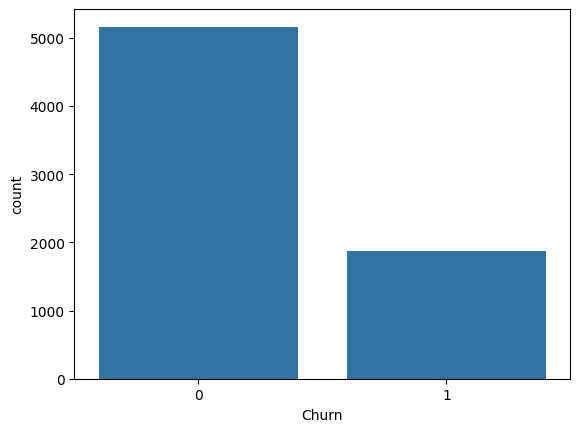

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.show()



* Imbalanced dataset.



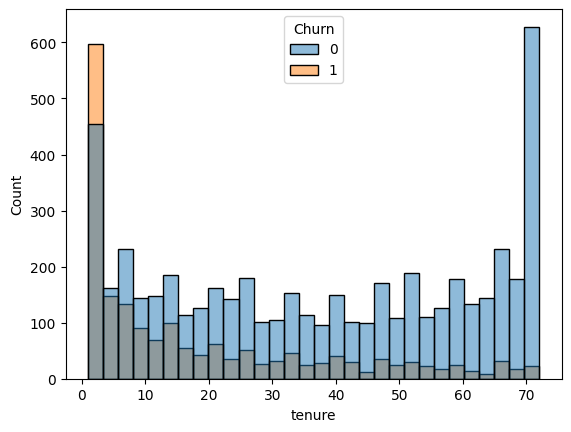

In [58]:
sns.histplot(data=df, x="tenure", hue="Churn", bins=30)
plt.show()



*   Customers with low tenure are more likely to churn, indicating that most churn happens early in the customer lifecycle.



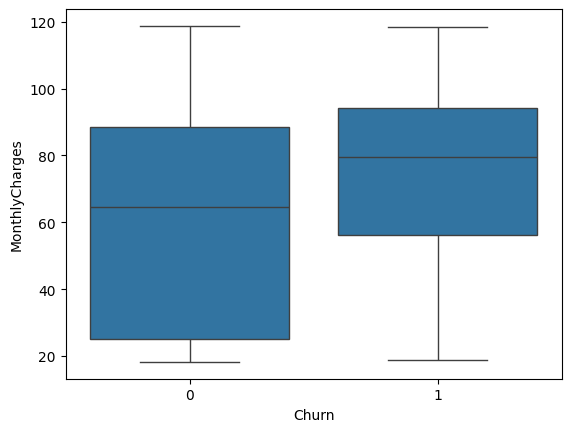

In [59]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()



*  Customers with higher monthly charges show a higher tendency to churn, indicating pricing sensitivity.



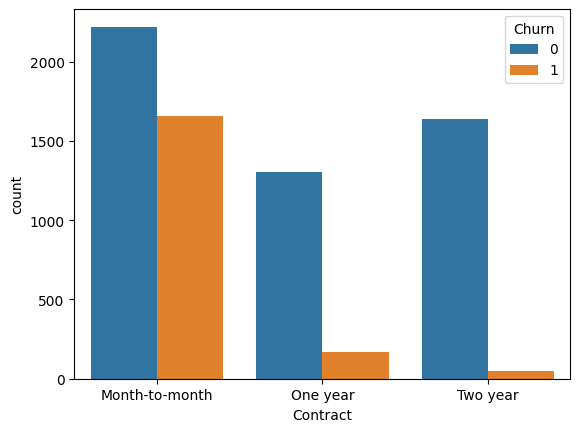

In [60]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.show()

In [61]:
df.groupby("Contract")["Churn"].mean()

Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn, dtype: float64



*  Customers with month-to-month contracts have significantly higher churn compared to long-term contract customers, suggesting lack of commitment increases churn risk.



In [62]:
df.groupby("InternetService")["Churn"].mean()

InternetService
DSL            0.189983
Fiber optic    0.418928
No             0.074342
Name: Churn, dtype: float64



*  Customers using fiber optic internet have higher churn rates, possibly due to higher costs or service expectations.


**FEATURE ENGINEERING**

**Tenure Bucketing**

In [63]:
def tenure_group(x):
    if x <= 12:
        return "0-1_year"
    elif x <= 24:
        return "1-2_years"
    elif x <= 48:
        return "2-4_years"
    else:
        return "4+_years"

df["tenure_group"] = df["tenure"].apply(tenure_group)

**Total Services Used**

In [64]:
services = [
    "PhoneService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies"
]

for col in services:
    df[col] = df[col].apply(lambda x: 1 if x == "Yes" else 0)

df["total_services"] = df[services].sum(axis=1)

**Spend Per Tenure** - Identifies high-value vs low-value customers

In [65]:
df["avg_monthly_spend"] = df["TotalCharges"] / (df["tenure"] + 1)

**Contract Encoding**

In [66]:
df = pd.get_dummies(df, columns=["Contract"], drop_first=True)

In [67]:
if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

In [68]:
cat_cols = df.select_dtypes(include="object").columns
print(cat_cols)

Index(['gender', 'Partner', 'Dependents', 'MultipleLines', 'InternetService',
       'PaperlessBilling', 'PaymentMethod', 'tenure_group'],
      dtype='object')


In [69]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "avg_monthly_spend"]

df[num_cols] = scaler.fit_transform(df[num_cols])

**Splitting Data**

In [71]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Balancing Data through SMOTE**

In [72]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [73]:
print(y_train.value_counts())

Churn
1    4130
0    4130
Name: count, dtype: int64


In [74]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [75]:
df.shape

(7032, 30)

**Import Models**

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

**Train Logistic Regression**

In [77]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

**Save the best model**

In [78]:
import joblib

joblib.dump(lr, "../models/model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(X_train.columns.tolist(), "../models/columns.pkl")

['../models/columns.pkl']

In [92]:
import joblib

cols = joblib.load("../models/columns.pkl")
print(len(cols))
print(cols)  # just preview

29
['SeniorCitizen', 'tenure', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MonthlyCharges', 'TotalCharges', 'total_services', 'avg_monthly_spend', 'Contract_One year', 'Contract_Two year', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'tenure_group_1-2_years', 'tenure_group_2-4_years', 'tenure_group_4+_years']


**Train Random Forest**

In [79]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

**Evaluate Models**

In [80]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

In [81]:
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")

--- Logistic Regression ---
Accuracy: 0.7540867093105899
F1 Score: 0.6085972850678733
ROC-AUC: 0.7429751360193818
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1033
           1       0.53      0.72      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407

--- Random Forest ---
Accuracy: 0.767590618336887
F1 Score: 0.5855513307984791
ROC-AUC: 0.7197625419964695
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1033
           1       0.56      0.62      0.59       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.77      0.77      1407



**Train XGBoost**

In [83]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss')

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

evaluate_model(y_test, y_pred_xgb, "XGBoost")

--- XGBoost ---
Accuracy: 0.7526652452025586
F1 Score: 0.5693069306930693
ROC-AUC: 0.7087451014903894
              precision    recall  f1-score   support

           0       0.85      0.80      0.83      1033
           1       0.53      0.61      0.57       374

    accuracy                           0.75      1407
   macro avg       0.69      0.71      0.70      1407
weighted avg       0.77      0.75      0.76      1407



**Feature Importance**

In [84]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X_train.columns)
feature_importance.sort_values(ascending=False).head(10)

tenure                            0.136237
TotalCharges                      0.126887
MonthlyCharges                    0.119615
avg_monthly_spend                 0.109329
PaymentMethod_Electronic check    0.056872
InternetService_Fiber optic       0.054457
Contract_Two year                 0.034736
OnlineSecurity                    0.031037
PaperlessBilling_Yes              0.029651
total_services                    0.029386
dtype: float64

**Install MLflow**

In [85]:
pip install mlflow # type: ignore

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [86]:
import mlflow
import os

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

mlflow.set_tracking_uri(f"file:{BASE_DIR}/mlruns")
mlflow.set_experiment("customer-churn-mlops")

<Experiment: artifact_location='file:c:\\Users\\HP\\OneDrive\\Documents\\customer-churn-mlops/mlruns/439024116829602353', creation_time=1777662608905, experiment_id='439024116829602353', last_update_time=1777662608905, lifecycle_stage='active', name='customer-churn-mlops', tags={}, trace_location=None, workspace='default'>

**LOG LOGISTIC REGRESSION**

In [87]:
mlflow.end_run() 
with mlflow.start_run():

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)

    mlflow.log_param("model", "LogisticRegression")

    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", auc)

    mlflow.sklearn.log_model(model, "model")

2026/05/03 11:02:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 11:02:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


**LOG RANDOM FOREST**

In [88]:
mlflow.end_run()  # ensure no active run

with mlflow.start_run():

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)

    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 100)

    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", auc)

    mlflow.sklearn.log_model(model, "model")

2026/05/03 11:03:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 11:03:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


**LOG XGBOOST (MULTIPLE RUNS)**

In [89]:
mlflow.end_run() 
params_list = [
    {"max_depth": 3, "learning_rate": 0.1, "n_estimators": 100},
    {"max_depth": 5, "learning_rate": 0.05, "n_estimators": 200},
    {"max_depth": 7, "learning_rate": 0.1, "n_estimators": 300},
]

for params in params_list:

    with mlflow.start_run():

        model = XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            **params
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred)

        mlflow.log_param("model", "XGBoost")
        mlflow.log_params(params)

        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("roc_auc", auc)

        mlflow.sklearn.log_model(model, "model")

c:\Users\HP\OneDrive\Documents\customer-churn-mlops\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:03:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2026/05/03 11:03:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 11:03:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
c:\Users\HP\OneDrive\Documents\customer-churn-mlops\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:03:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameter

In [90]:
print(len(X_train.columns))
print(X_train.columns.tolist())

29
['SeniorCitizen', 'tenure', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MonthlyCharges', 'TotalCharges', 'total_services', 'avg_monthly_spend', 'Contract_One year', 'Contract_Two year', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'tenure_group_1-2_years', 'tenure_group_2-4_years', 'tenure_group_4+_years']


In [93]:
joblib.dump(num_cols, "../models/num_cols.pkl")

['../models/num_cols.pkl']